# Profit Prediction with Machine Learning

## Goal
Predict **Profit** from pre-sale features using two models — **Linear Regression** and **Random Forest** — then compare their performance to determine which is more suitable.

## Why we exclude certain columns (data leakage)
Columns like `Sales`, `COGS`, `Gross Sales`, and `Discounts` are **derived from Profit** (Profit = Sales − COGS). Using them as features would leak the target into the inputs, producing artificially perfect predictions that would not generalise to new data. We only keep features that are known **before** the sale outcome: product information, segment, country, discount band, units sold, prices, and date components.

## 1. Setup & Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Load and clean data (reusing logic from Data_cleaning.py)
from Data_cleaning import clean_data

df = pd.read_excel("Sample_data.xlsx")
df = clean_data(df)
print(f"Dataset shape after cleaning: {df.shape}")
df.head()

Dataset shape after cleaning: (700, 13)


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date
0,Government,Germany,Carretera,None,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01
1,Government,Germany,Paseo,None,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01
2,Government,Canada,Paseo,None,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,2013-11-01
3,Government,Germany,Paseo,None,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01
4,Government,Germany,Velo,None,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01


In [3]:
# Extract date features before dropping Date
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

# Select features known before the sale outcome
feature_cols = ["Segment", "Country", "Product", "Discount Band",
                "Units Sold", "Manufacturing Price", "Sale Price",
                "Month", "Year"]
target_col = "Profit"

data = df[feature_cols + [target_col]].copy()
print(f"Features: {feature_cols}")
print(f"Target: {target_col}")
print(f"Working dataset shape: {data.shape}")
data.head()

Features: ['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Month', 'Year']
Target: Profit
Working dataset shape: (700, 10)


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Month,Year,Profit
0,Government,Germany,Carretera,None,1513.0,3,350,12,2014,136170.0
1,Government,Germany,Paseo,None,1006.0,10,350,6,2014,90540.0
2,Government,Canada,Paseo,None,1725.0,10,350,11,2013,155250.0
3,Government,Germany,Paseo,None,1513.0,10,350,12,2014,136170.0
4,Government,Germany,Velo,None,1006.0,120,350,6,2014,90540.0


## 2. Exploratory Analysis for ML

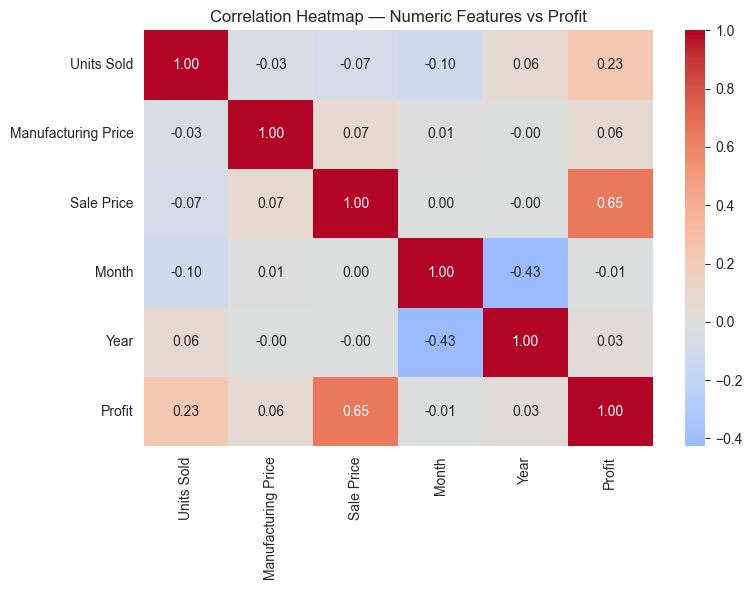

In [4]:
# Correlation heatmap of numeric features vs Profit
numeric_cols = ["Units Sold", "Manufacturing Price", "Sale Price", "Month", "Year", "Profit"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap — Numeric Features vs Profit")
plt.tight_layout()
plt.show()

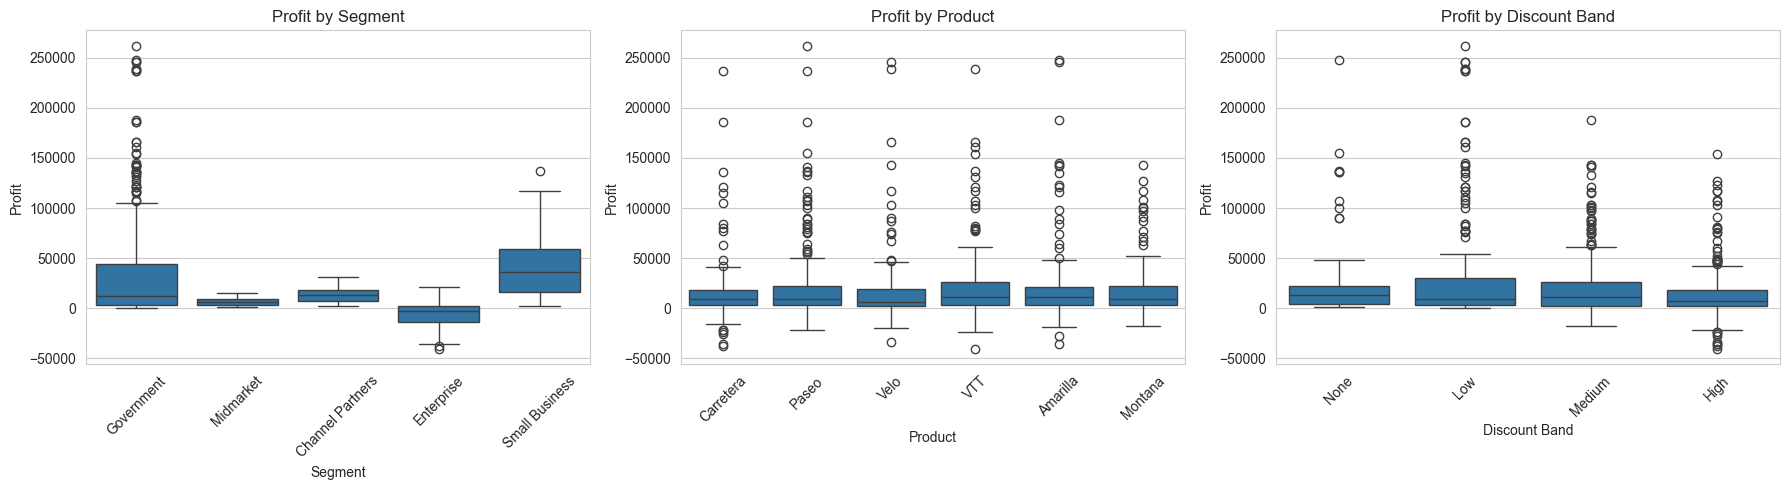

In [5]:
# Box plots of Profit by categorical features
cat_cols = ["Segment", "Product", "Discount Band"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    sns.boxplot(data=data, x=col, y="Profit", ax=ax)
    ax.set_title(f"Profit by {col}")
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

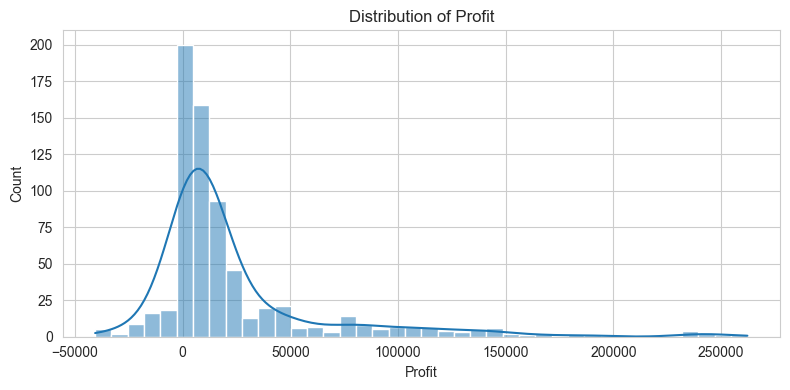

In [6]:
# Distribution of Profit
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data["Profit"], bins=40, kde=True, ax=ax)
ax.set_title("Distribution of Profit")
ax.set_xlabel("Profit")
plt.tight_layout()
plt.show()

## 3. Feature Engineering & Preprocessing

In [7]:
# One-hot encode categorical features
cat_features = ["Segment", "Country", "Product", "Discount Band"]
data_encoded = pd.get_dummies(data, columns=cat_features, drop_first=True, dtype=int)

# Train / Test split (80/20)
X = data_encoded.drop(columns=[target_col])
y = data_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:  X={X_train.shape}, y={y_train.shape}")
print(f"Test set:      X={X_test.shape},  y={y_test.shape}")

Training set:  X=(560, 21), y=(560,)
Test set:      X=(140, 21),  y=(140,)


## 4. Model 1 — Linear Regression

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr_train = lr.predict(X_train)
y_pred_lr = lr.predict(X_test)

lr_train_r2 = r2_score(y_train, y_pred_lr_train)
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = root_mean_squared_error(y_test, y_pred_lr)

print("Linear Regression — Test Metrics")
print(f"  R²:   {lr_r2:.4f}")
print(f"  MAE:  {lr_mae:,.2f}")
print(f"  RMSE: {lr_rmse:,.2f}")
print(f"  Train R²: {lr_train_r2:.4f}")

Linear Regression — Test Metrics
  R²:   0.6760
  MAE:  17,932.03
  RMSE: 26,119.20
  Train R²: 0.7586


In [9]:
# Coefficients table — top features by absolute weight
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("Top 15 coefficients (by absolute value):")
coef_df.head(15)

Top 15 coefficients (by absolute value):


,Feature,Coefficient
5,Segment_Enterprise,-51215.098450
8,Segment_Small Business,-48303.271520
18,Discount Band_Low,25214.748067
20,Discount Band_None,18783.491070
19,Discount Band_Medium,10142.104842
7,Segment_Midmarket,-6884.770808
12,Country_United States of America,-5070.577583
10,Country_Germany,4185.189076
6,Segment_Government,-3355.270120
17,Product_Velo,3066.040627


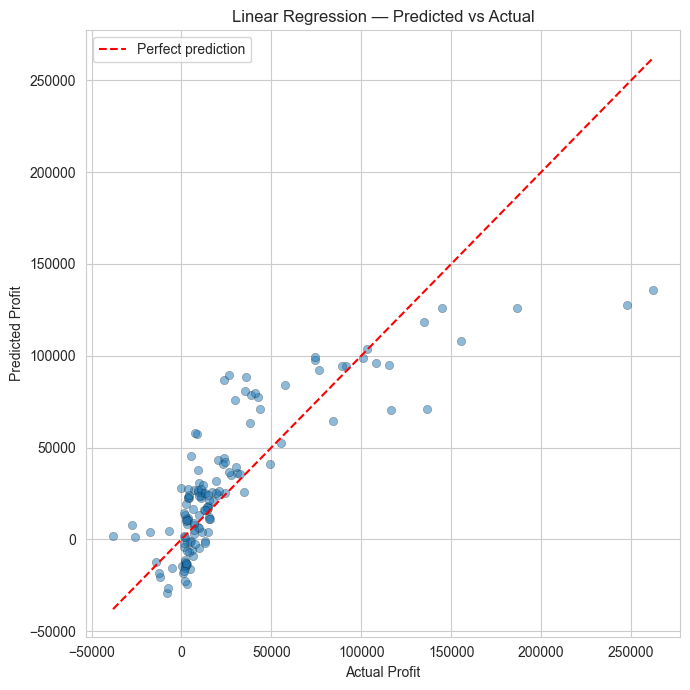

In [10]:
# Predicted vs Actual scatter plot
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_lr, alpha=0.5, edgecolors="k", linewidths=0.3)
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlabel("Actual Profit")
ax.set_ylabel("Predicted Profit")
ax.set_title("Linear Regression — Predicted vs Actual")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Model 2 — Random Forest

In [11]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf_train = rf.predict(X_train)
y_pred_rf = rf.predict(X_test)

rf_train_r2 = r2_score(y_train, y_pred_rf_train)
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)

print("Random Forest — Test Metrics")
print(f"  R²:   {rf_r2:.4f}")
print(f"  MAE:  {rf_mae:,.2f}")
print(f"  RMSE: {rf_rmse:,.2f}")
print(f"  Train R²: {rf_train_r2:.4f}")

Random Forest — Test Metrics
  R²:   0.9244
  MAE:  4,834.56
  RMSE: 12,616.51
  Train R²: 0.9912


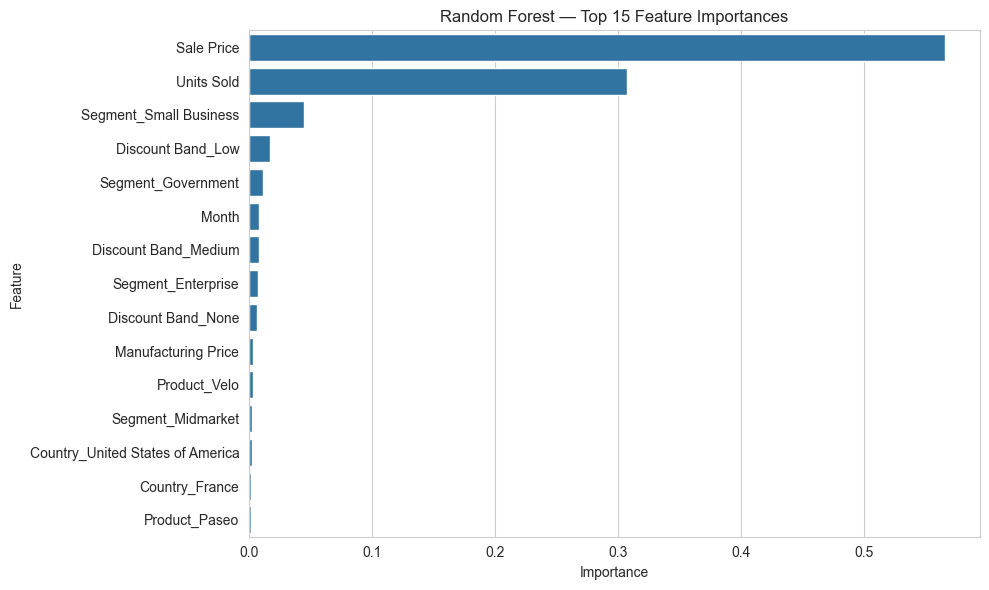

In [12]:
# Feature importance bar chart
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importances.head(15), x="Importance", y="Feature", ax=ax)
ax.set_title("Random Forest — Top 15 Feature Importances")
plt.tight_layout()
plt.show()

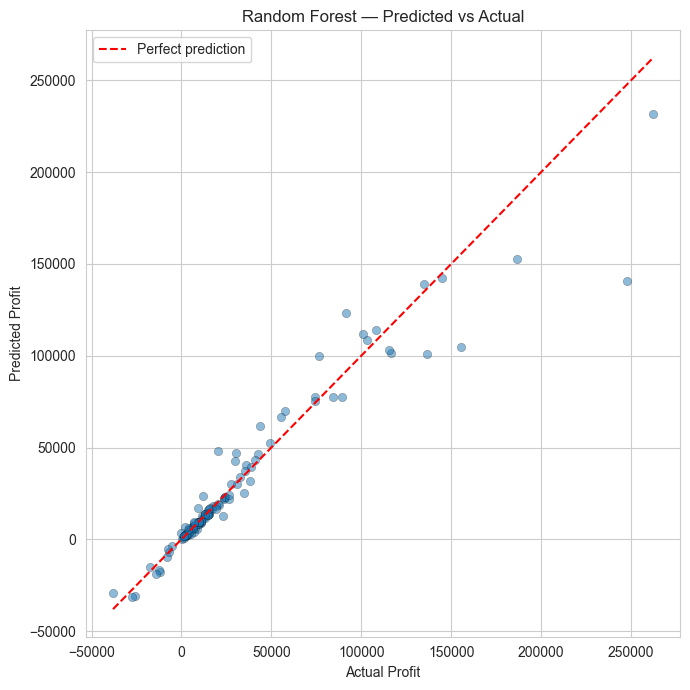

In [13]:
# Predicted vs Actual scatter plot
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_rf, alpha=0.5, edgecolors="k", linewidths=0.3)
lims = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlabel("Actual Profit")
ax.set_ylabel("Predicted Profit")
ax.set_title("Random Forest — Predicted vs Actual")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Model Comparison

In [14]:
# Side-by-side metrics table
comparison = pd.DataFrame({
    "Metric": ["R² (test)", "MAE", "RMSE", "R² (train)"],
    "Linear Regression": [lr_r2, lr_mae, lr_rmse, lr_train_r2],
    "Random Forest": [rf_r2, rf_mae, rf_rmse, rf_train_r2],
})
comparison

,Metric,Linear Regression,Random Forest
0,R² (test),0.676047,0.924414
1,MAE,17932.028480,4834.556994
2,RMSE,26119.197612,12616.511780
3,R² (train),0.758611,0.991218


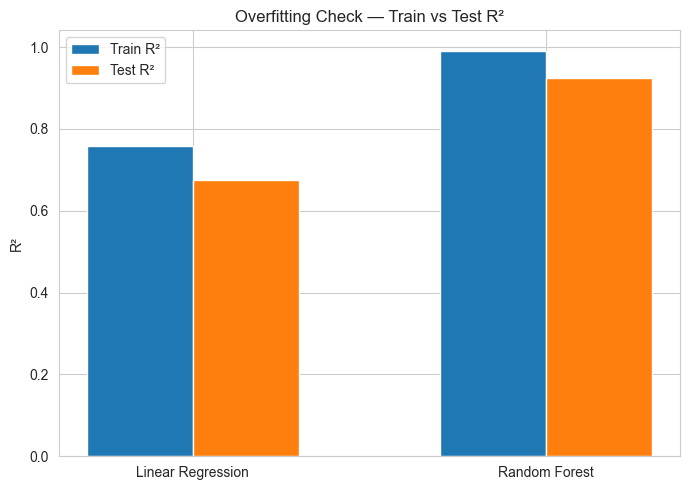

In [15]:
# Overfitting check — Train vs Test R²
models = ["Linear Regression", "Random Forest"]
train_scores = [lr_train_r2, rf_train_r2]
test_scores = [lr_r2, rf_r2]

x_pos = np.arange(len(models))
width = 0.3

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x_pos - width/2, train_scores, width, label="Train R²")
ax.bar(x_pos + width/2, test_scores, width, label="Test R²")
ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.set_ylabel("R²")
ax.set_title("Overfitting Check — Train vs Test R²")
ax.legend()
plt.tight_layout()
plt.show()

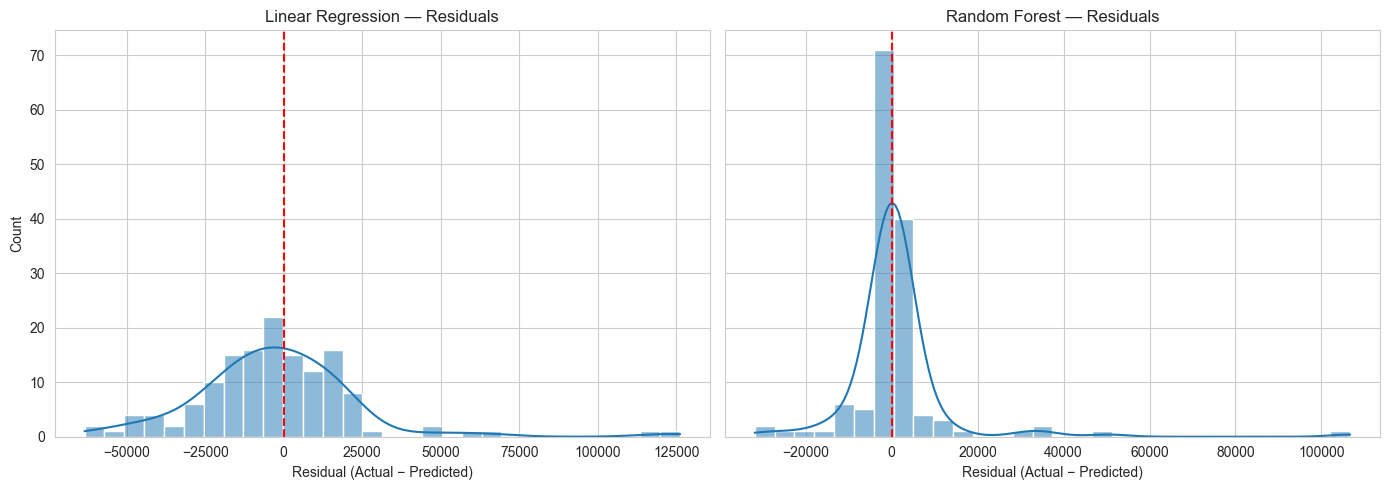

In [16]:
# Residual distribution plots
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(residuals_lr, bins=30, kde=True, ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Linear Regression — Residuals")
axes[0].set_xlabel("Residual (Actual − Predicted)")

sns.histplot(residuals_rf, bins=30, kde=True, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Random Forest — Residuals")
axes[1].set_xlabel("Residual (Actual − Predicted)")

fig.tight_layout()
plt.show()

In [17]:
# Verdict
best = "Random Forest" if rf_r2 > lr_r2 else "Linear Regression"
print(f"Best model: {best}")
print()
if best == "Random Forest":
    print("The Random Forest outperforms Linear Regression because:")
    print(f"  • Higher R² ({rf_r2:.4f} vs {lr_r2:.4f}) — it explains more variance in Profit.")
    print(f"  • Lower MAE ({rf_mae:,.2f} vs {lr_mae:,.2f}) — its average error is smaller.")
    print(f"  • Lower RMSE ({rf_rmse:,.2f} vs {lr_rmse:,.2f}) — it handles large errors better.")
    print()
    print("  Random Forest captures non-linear relationships and interactions between")
    print("  features (e.g., Units Sold × Manufacturing Price) that Linear Regression misses.")
    gap = rf_train_r2 - rf_r2
    if gap > 0.15:
        print(f"\n  ⚠ Note: the train-test R² gap ({gap:.4f}) suggests some overfitting.")
        print("  Hyperparameter tuning (max_depth, min_samples_leaf) could reduce this.")
    else:
        print(f"\n  The train-test R² gap ({gap:.4f}) is moderate, indicating acceptable generalisation.")
else:
    print("Linear Regression outperforms Random Forest on this dataset.")
    print(f"  • Higher R² ({lr_r2:.4f} vs {rf_r2:.4f})")
    print(f"  • Lower MAE ({lr_mae:,.2f} vs {rf_mae:,.2f})")
    print(f"  • Lower RMSE ({lr_rmse:,.2f} vs {rf_rmse:,.2f})")
    print("  This suggests the relationship between features and Profit is mostly linear.")

Best model: Random Forest

The Random Forest outperforms Linear Regression because:
  • Higher R² (0.9244 vs 0.6760) — it explains more variance in Profit.
  • Lower MAE (4,834.56 vs 17,932.03) — its average error is smaller.
  • Lower RMSE (12,616.51 vs 26,119.20) — it handles large errors better.

  Random Forest captures non-linear relationships and interactions between
  features (e.g., Units Sold × Manufacturing Price) that Linear Regression misses.

  The train-test R² gap (0.0668) is moderate, indicating acceptable generalisation.


## 7. Conclusion

### Summary
We built two models to predict Profit from pre-sale features, carefully excluding columns that would cause data leakage (`Sales`, `COGS`, `Gross Sales`, `Discounts`).

**Key predictive features** (from both coefficient analysis and feature importance):
- **Units Sold** — the dominant driver of profit magnitude.
- **Manufacturing Price / Sale Price** — directly determine margins.
- **Discount Band** — higher discounts reduce profit margins.
- **Product** — different products have different cost structures.

### Business Interpretation
- Volume (Units Sold) is the single strongest predictor of profit.
- Pricing structure (Manufacturing Price, Sale Price) defines the per-unit margin.
- Discount levels have a visible impact — moving from "None" to "High" reduces expected profit.
- The model can help forecast expected profit for new orders based on product, customer segment, pricing, and discount band.